# Машинное обучение. ВМК МГУ

# Практическое задание 10: Градиентный бустинг деревьев - часть 1

## Уровень: **Базовый (Base)**

# О формате сдачи

🔷 При решении ноутбука используйте данный шаблон

```
✅ Можно добавлять новые ячейки любых типов
❌ Не нужно удалять текстовые ячейки c разметкой частей ноутбука и формулировками заданий
```

🔷 При оценивании задач учитывается код

```
✅ Задания, в которых необходим код, обычно помечаются фразами "Your code here"/"Ваш код" и аналогичными
❌ Ответы на вопросы без сопутствующего кода оцениваются в 0 баллов
❌ Наличе работоспособного кода в ноутбуке, если на сказано иного, обязательно
```

🔷 При оценивании задач учитываются выводы

```
✅ Задания, в которых необходимы выводы, обычно помечаются фразами Вывод"/"Ответ на вопрос"/"Ваш текст" и аналогичными
✅ Обычно выводы подразумевают под собой текстовый ответ (можно писать markdown, latex).
✅ Сопутствующие изображения, графики, таблички - приветствуются!
❌ При отсутствии выводов задание не засчитается на полный балл
```

В этом задании вы..:

- Познакомитесь с несколькими новыми библиотеками машинного обучения
- Сравните между собой разные реализации градиентных бустингов

**Примерное время выполнения (execution
time/время выполнения, если нажать run all) всех ячеек ноутбука при
правильной реализации: не более 60 минут **

# Подготовка рабочей среды

Сначала установим нужные нам версии библиотек. Мы гарантируем, что в данных версиях задание будет корректно отрабатывать.

После установки нужных версий, возможно, нужно перезагрузить среду (runtime), но скорее всего вам это не понадобится

На скачивание файла и установку понадобится не более 5 минут.

**Важно!**

Устанавливать нужные версии нужно каждый раз, когда создается новый
рантайм. Например, если вы 2 часа подряд делаете это задание, то
подготовить библиотеки достаточно 1 раз. Но если вы, например, начали в
понедельник, затем закрыли/выключили ноутбук, то при продолжении в
среду, вам нужно будет запустить рантайм заново и следовательно заново
установить библиотеки.

**Важно!**
Если вы предпочитаете делать практические задания на своем личном ноутбуке, то проверьте, что вы установили рабочее окружение в соответствии с гайдом .pdf)

In [ ]:
# !!! Данный блок будет работать только в Google-Colab !!!
! gdown 10k8Hwn9kpK9SpK4IEj4-EaWQZqgYT5-Q
! pip install -r /content/requirements_2024_25_for_colab_small.txt

Downloading...
From: https://drive.google.com/uc?id=10k8Hwn9kpK9SpK4IEj4-EaWQZqgYT5-Q
To: /content/requirements_2024_25_for_colab_small.txt
100% 375/375 [00:00<00:00, 1.15MB/s]


In [ ]:
import catboost
assert(catboost.__version__ == '1.2.7')

Теперь можно приступать к выполнению задания! :)

## Введение

Привет, ребятушки!

Сегодня мы с вами будем решать очень важную задачу, а именно
оценивать цену поддержанных автомобилей в ряде стран. Делать мы это
будем с помощью различных методов градиентного бустинга. Мы с вами
узнаем, что в мире существует не только sklearn, и что существуют
библиотеки, облегчающие нам задачу поиска оптимальных параметров для
моделей.

**Внимание!** Во всех заданиях в качестве целевой метрики используется MAE (средняя абсолютная ошибка).

Значение MAE вычисляется как

M A E = N ∑ i = 1 | a ( x i ) − y i | N , M A E = ∑ i = 1 N | a ( x i ) − y i | N ,

где N N - число объектов в тестовой выборке, x i x i - вектор признаков i-го объекта, a ( x i ) a ( x i ) - предсказание на i-ом объекте, y i y i - значение целевого признака на i-м объекте.

## Установка дополнительных библиотек.

В этом задании нам понадобятся три бибиотеки, которыми вы ранее не пользовались в этом курсе, а именно:

**XGBoost**: Документация здесь .
**LightGBM**: Документация здесь . Также дополнительно про установку тут .
**Catboost**: Документация здесь . Можно найти также некоторую информацию на русском тут .
**HyperOpt**: Документация здесь .

**Внимание!** Вникать и подробно
читать документацию к каждой библиотеке нет необходимости! Достаточно
обращаться туда для нахождения примеров обучения.

## Подготовка датасета

Все библиотеки, используемые сегодня, мы будем проверять на одних и тех же параметрах:

n_estimators=1000, max_depth=5, learning_rate=0.1.

Таким образом мы устанавливаем, соответственно, число деревьев в
ансамбле равным 1000, ограничиваем максимальную глубину деревьев 5 и
устанавливаем темп обучения равным 0.1. Создадим сразу словарь, чтобы
передавать эти параметры создаваемым регрессорам (если вдруг не знали,
словарь можно передавать как параметры, поставив перед ним **).

Эти параметры мы вынесем в отдельную переменную test_parameters .

При желании можно почитать про этот датасет на платформе kaggle: ссылка на данные . Не скачивайте датасет из kaggle для выполнения ноутбука, поскольку его могут изменить.
Нас интересует файл dataframe_YesIndex_YesHeader_C.csv, поскольку он
уже хорошо предобработан (хотя, конечно, датасаентисты должны сами уметь
это делать, но ладно).
Давайте попробуем загрузить датасет в память и посмотреть, как он
выглядит.

При работе в google colab для скачивания датасета достаточно запустить следующую ячейку.

При работе с ноутбуком на локальном компьютере Вы можете скачать файл по этой ссылке и чуть ниже заменить /content/dataframe_YesIndex_YesHeader_C.csv (в строке с read_csv ) на ваш локальный путь до файла.

In [ ]:
# при локальном выполнении запускать эту ячейку НЕ НАДО
!gdown 1gdDv2kTCEkF3ia1vvbvRFJM0YfqmPplb

Downloading...
From: https://drive.google.com/uc?id=1gdDv2kTCEkF3ia1vvbvRFJM0YfqmPplb
To: /content/dataframe_YesIndex_YesHeader_C.csv
100% 568k/568k [00:00<00:00, 100MB/s]


In [ ]:
%matplotlib inline
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import mean_absolute_error, make_scorer

from hyperopt import hp, tpe, Trials
from hyperopt.fmin import fmin
from hyperopt.pyll import scope

from xgboost import XGBRegressor

from lightgbm import LGBMRegressor

from catboost import CatBoostRegressor

import matplotlib.pyplot as plt

import pandas as pd

import numpy as np

import time

In [ ]:
test_parameters = {"n_estimators": 1000, "max_depth": 5, "learning_rate":0.1}

df = pd.read_csv('/content/dataframe_YesIndex_YesHeader_C.csv', index_col=0)
df.head()

,Engine Capacity,Cylinders,Drive Type,Fuel Tank Capacity,Fuel Economy,Fuel Type,Horsepower,Torque,Transmission,Top Speed,...,Acceleration,Length,Width,Height,Wheelbase,Trunk Capacity,name,price,currency,Country
0,1.2,3,0,42.0,4.9,0,76,100.0,0,170,...,14.0,4.245,1.670,1.515,2.550,450.0,Mitsubishi Attrage 2021 1.2 GLX (Base),34099.0,0,0
1,1.2,3,0,42.0,4.9,0,76,100.0,0,170,...,14.0,4.245,1.670,1.515,2.550,450.0,Mitsubishi Attrage 2021 1.2 GLX (Base),34099.0,0,0
2,1.4,4,0,45.0,6.3,0,75,118.0,1,156,...,16.0,3.864,1.716,1.721,2.513,2800.0,Fiat Fiorino 2021 1.4L Standard,41250.0,0,0
3,1.6,4,0,50.0,6.4,0,102,145.0,0,180,...,11.0,4.354,1.994,1.529,2.635,510.0,Renault Symbol 2021 1.6L PE,44930.0,0,0
4,1.5,4,0,48.0,5.8,0,112,150.0,0,170,...,10.9,4.314,1.809,1.624,2.585,448.0,MG ZS 2021 1.5L STD,57787.0,0,0


### **Задание 0 [без проверки, 0 баллов]**

Посмотрите
на цены автомобилей. Попробуйте понять, написаны они в одной валюте или
нет. Если нет -- будут ли у нас серьезные проблемы при использовании
деревьев? Стоит ли нам что-то сделать для того, чтобы нивелировать эту
проблему?

В глаза бросаются две проблемы: у нас имеется информация о
производителе автомобиля, скрытая в текстовой переменной модели
автомобиля (нет отдельного признака). Также имеются некоторые
категориальные переменные. Со всем этим безобразием надо что-то сделать.

In [ ]:
df['currency'].unique()

array([0, 1, 5, 3, 4, 2])


### **Задание 1 [2 балла]**

Данные : датасет со стоимостью подержанных автомобилей
Цели : В данном задании следует выполнить следующие пункты:

1. Изучить датасет, проверить наличие пропусков. Под пропусками подразумевается значение N/A вместо признака. При необходимости заменить их на среднее значение признака.
2. Добавить столбец brand с информацией о производителе автомобиля (для простоты можно взять первое слово в названии модели).
3. Решить, какие признаки Вы считаете категориальными. Конвертировать выбранные категориальные столбцы в тип category.
4. Создать датасет А , в котором выбранные категориальные
признаки установлены как категориальные. Для этого необходимо создать
вектор целевых значений Y (столбец цен автомобилей) и матрицу признаков
X, в которой все категориальные переменные помечены как
.astype('category'). Дополнительно стоит создать список с названиями и
индексами столбцов категориальных переменных (поможет в будущем).
5. Создать датасет B без категориальных признаков. Для этого необходимо просто удалить из матрицы признаков все категориальные переменные.
6. Создать датасет C , в котором выбранные категориальные
признаки закодированы через one-hot encoding. Для этого необходимо из
матрицы признаков удалить выбранные категориальные переменные, а затем
добавить новые признаки, соответствующие one-hot encoding этих
категориальных переменных (со всей этой магией поможет простая функция pd.get_dummies ).
7. Разбить датасеты на тренировочное и тестовое множества , используя train_test_split(X, y, test_size=0.25, random_state=0) (зафиксировав random_seed мы получим одинаковое разбиение на обучение/тест для всех трёх выборок).

In [ ]:
print(df.columns)
if df.isna().sum().sum() == 0: print("Пропусков нет")
df['brand'] = df['name'].str.split(' ').str[0]
df = df.drop(columns = ['name'])

Index(['Engine Capacity', 'Cylinders', 'Drive Type', 'Fuel Tank Capacity',
       'Fuel Economy', 'Fuel Type', 'Horsepower', 'Torque', 'Transmission',
       'Top Speed', 'Seating Capacity', 'Acceleration', 'Length', 'Width',
       'Height', 'Wheelbase', 'Trunk Capacity', 'name', 'price', 'currency',
       'Country'],
      dtype='object')
Пропусков нет


In [ ]:
df['brand'] = df['brand'].astype("category")
df['Fuel Type'] = df['Fuel Type'].astype("category")
df['Seating Capacity'] = df['Seating Capacity'].astype("category")
df['Country'] = df['Country'].astype("category")
df['Drive Type'] = df['Drive Type'].astype("category")
df['currency'] = df['currency'].astype("category")



dfA_X = df.copy()
dfA_Y = dfA_X['price']
dfA_X = dfA_X.drop(columns=['price'])

dfB = dfA_X.drop(columns=['brand', 'Fuel Type', 'Seating Capacity', 'Country', 'Drive Type', 'currency'])

dfC = pd.get_dummies(dfA_X, columns=['brand', 'Fuel Type', 'Seating Capacity', 'Country', 'Drive Type', 'currency'])

datasets = {'A': None, 'B': None, 'C': None}


datasets['A'] = train_test_split(dfA_X, dfA_Y, test_size=0.25, random_state=0)
datasets['B'] = train_test_split(dfB, dfA_Y, test_size=0.25, random_state=0)
datasets['C'] = train_test_split(dfC, dfA_Y, test_size=0.25, random_state=0)

Итак, кажется, что у нас всё готово для того, чтобы начать искать
ответы на волнующие нас вопросы. Начнем со столь любимой нами
библиотеки, а именно...

## Градиентный бустинг со sklearn

Естественно, в sklearn имеется реализация градиентного бустинга, которая хранится в sklearn.ensemble.GradientBoostingRegressor .
Преимущественно данным классом пользуются в учебных заданиях, а в
реальных задачах предпочтение отдаётся другим библиотекам. Давайте
попробуем понять, заслуженно ли градиентный бустинг в sklearn не
пользуется популярностью.

FYI: в sklearn имеется также реализация GradientBoostingClassifier для задач классификации, но пользоваться им мы сегодня не будем.

GradientBoostingRegressor из коробки не умеет работать с категориальными признаками. Мы к этому уже подготовились, закодировав наши признаки.

### **Задание 2 [1.5 баллa]**

Данные : датасет со стоимостью поддержанных автомобилей
Метрика : MAE
Цели : В данном задании следует выполнить следующие пункты:

1. Обучить sklearn.ensemble.GradientBoostingRegressor на датасетах B и C (получится два разных регрессора), используя параметры n_estimators=1000, max_depth=5, learning_rate=0.1 (наши test_parameters ). Замерить время обучения.
2. Посчитать MAE для предсказаний на соответствующих
тренировочном и тестовом множествах (можно воспользоваться
sklearn.metrics.mean_absolute_error). Замерить время предсказания.
3. Вывести в таблице DataFrame результаты о времени обучения, времени предсказания, MAE на тренировочном и тестовом множествах.
**Внимание!** Для каждого из последующих
заданий создавайте новые переменные для таблиц DataFrame - в задании 6
необходимо будет объединить все полученные результаты
4. Сделайте выводы. Оцените полезность категориальных
переменных. Оцените время, затраченное на обучение. Попробуйте дать
оценку получившемуся MAE: оно большое или маленькое?

In [ ]:
import time

df_skl = pd.DataFrame(columns=['Dataset', 'Training time', 'Prediction time', 'Train MAE', 'Test MAE'])

gbrB = GradientBoostingRegressor(**test_parameters)
gbrC = GradientBoostingRegressor(**test_parameters)

start_time = time.time()
gbrB = gbrB.fit(datasets['B'][0], datasets['B'][2])

time_B = time.time() - start_time
print(f"Градиентный бустинг на модели B учился {time_B} секунд")

start_time = time.time()
gbrC = gbrC.fit(datasets['C'][0], datasets['C'][2])

time_C = time.time() - start_time
print(f"Градиентный бустинг на модели C учился {time_C} секунд")

Градиентный бустинг на модели B учился 11.856043100357056 секунд
Градиентный бустинг на модели C учился 20.251712322235107 секунд


In [ ]:
start_time = time.time()
train_mae_B = mean_absolute_error(datasets['B'][2], gbrB.predict(datasets['B'][0]))
test_mae_B = mean_absolute_error(datasets['B'][3], gbrB.predict(datasets['B'][1]))
ptime_B =( time.time() - start_time)/2

start_time = time.time()
train_mae_С = mean_absolute_error(datasets['C'][2], gbrC.predict(datasets['C'][0]))
test_mae_С = mean_absolute_error(datasets['C'][3], gbrC.predict(datasets['C'][1]))
ptime_C =( time.time() - start_time)/2

print(f"Ошибка B на трейне: {train_mae_B}")
print(f"Ошибка B на тесте: {test_mae_B}")

print(f"Ошибка С на трейне: {train_mae_С}")
print(f"Ошибка С на тесте: {test_mae_С}")

Ошибка B на трейне: 91994.96518368524
Ошибка B на тесте: 123305.56297084712
Ошибка С на трейне: 4454.708997804025
Ошибка С на тесте: 18290.002249013975


In [ ]:
df_skl.loc[len(df_skl)] = {'Dataset': 'B', 'Training time': time_B, 'Prediction time': ptime_B, 'Train MAE': train_mae_B, 'Test MAE': test_mae_B}
df_skl.loc[len(df_skl)] = {'Dataset': 'C', 'Training time': time_C, 'Prediction time': ptime_C, 'Train MAE': train_mae_С, 'Test MAE': test_mae_С}

df_skl

,Dataset,Training time,Prediction time,Train MAE,Test MAE
0,B,11.856043,0.048645,91994.965184,123305.562971
1,C,20.251712,0.053519,4454.708998,18290.002249


Ваши выводы: В
обоих случаях модель с категориальными пере менными показала лучший
результат. Это означает, что они полезны, и от них нельзя отказываться

И так, sklearn предлагает нам привычный и простой способ тренировки
моделей. Однако, для градиентного бустинга существует множество эвристик
и трюков, помогающих улучшить результаты. И одна из библиотек,
реализующая улучшенную версию бустинга, называется xgboost.

## Градиентный бустинг с XGBoost

**XGBoost**
стала достаточно популярной библиотекой, которая позволяет добиться
хороших результатов без особых усилий (во всяком случае, так гласят
легенды). И у нас для вас две новости: хорошая и плохая. Хорошая –
xgboost, хоть и является сторонней библиотекой, сохраняет интерфейс
sklearn. Плохая – она тоже не умеет из коробки работать с
категориальными признаками. Ну что же, давайте пощупаем это безобразие.
На этот раз нас интересует класс xgboost.XGBRegressor.

**Daily Fact:** на самом деле в
xgboost есть экспериментальная поддержка категориальных переменных,
которая еще не добавлена в стабильную версию, поэтому ею мы пользоваться
не будем.

### **Задание 3 [1.5 баллa]**

Данные : датасет со стоимостью поддержанных автомобилей
Метрика : MAE
Цели : В данном задании следует выполнить следующие пункты:

1. Обучить xgboost.XGBRegressor на датасетах B и C , используя параметры n_estimators=1000, max_depth=5, learning_rate=0.1 (наши test_parameters ). Замерить время обучения.
2. Посчитать MAE для полученных предсказаний на соответствующих тренировочном и тестовом множествах (можно воспользоваться sklearn.metrics.mean_absolute_error ). Замерить время предсказания
3. Вывести в таблице DataFrame результаты о времени обучения, времени предсказания, MAE на тренировочном и тестовом множествах.
4. Сделайте выводы. Оцените время, затраченное на обучение, сравните с sklearn.

In [ ]:
import xgboost

df_xgb = pd.DataFrame(columns=['Dataset', 'Training time', 'Prediction time', 'Train MAE', 'Test MAE'])

xgbrB = xgboost.XGBRegressor(**test_parameters)
xgbrC = xgboost.XGBRegressor(**test_parameters)

start_time = time.time()
xgbrB = xgbrB.fit(datasets['B'][0], datasets['B'][2])

time_B = time.time() - start_time
print(f"Градиентный бустинг на модели B учился {time_B} секунд")

start_time = time.time()
xgbrC = xgbrC.fit(datasets['C'][0], datasets['C'][2])

time_C = time.time() - start_time
print(f"Градиентный бустинг на модели C учился {time_C} секунд")

Градиентный бустинг на модели B учился 1.3813807964324951 секунд
Градиентный бустинг на модели C учился 4.2145750522613525 секунд


In [ ]:
start_time = time.time()
train_mae_B = mean_absolute_error(datasets['B'][2], xgbrB.predict(datasets['B'][0]))
test_mae_B = mean_absolute_error(datasets['B'][3], xgbrB.predict(datasets['B'][1]))
ptime_B =( time.time() - start_time)/2

start_time = time.time()
train_mae_С = mean_absolute_error(datasets['C'][2], xgbrC.predict(datasets['C'][0]))
test_mae_С = mean_absolute_error(datasets['C'][3], xgbrC.predict(datasets['C'][1]))
ptime_C =( time.time() - start_time)/2

print(f"Ошибка B на трейне: {train_mae_B}")
print(f"Ошибка B на тесте: {test_mae_B}")

print(f"Ошибка С на трейне: {train_mae_С}")
print(f"Ошибка С на тесте: {test_mae_С}")

Ошибка B на трейне: 92667.26664239538
Ошибка B на тесте: 123038.86217726323
Ошибка С на трейне: 5494.760309060973
Ошибка С на тесте: 18395.56262582478


In [ ]:
df_xgb.loc[len(df_xgb)] = {'Dataset': 'B', 'Training time': time_B, 'Prediction time': ptime_B, 'Train MAE': train_mae_B, 'Test MAE': test_mae_B}
df_xgb.loc[len(df_xgb)] = {'Dataset': 'C', 'Training time': time_C, 'Prediction time': ptime_C, 'Train MAE': train_mae_С, 'Test MAE': test_mae_С}

df_xgb

,Dataset,Training time,Prediction time,Train MAE,Test MAE
0,B,1.381381,0.098593,92667.266642,123038.862177
1,C,4.214575,0.152197,5494.760309,18395.562626


Ваши выводы: Время, затраченное на обучение, значительно уменьшилось по сравнению с sklearn. МАЕ остался примерно таким же

Таким вот несложным образом нам удалось воспользоваться еще одной
библиотекой. Давайте перейдем к третьей библиотеке, которую мы сегодня
изучим, и называется она lightgbm.

## Градиентный бустинг в lightgbm

Про **Lightgbm**
легенды гласят, что она очень быстрая и легкая: что самый большой
датасет она без проблем переварит за относительно небольшое время. А еще
её разрабатывали не хухры кто, а сами мелкомягкие, так что попробовать
её определённо стоит. На этот раз у нас вновь две новости, две хороших и
две плохих.

Первая хорошая — lightgbm тоже похож на sklearn. Вторая хорошая —
lightgbm умеет из коробки работать с категориальными признаками!

Плохая — делает она это немного нетривиально (не зря я просил вас
запомнить категориальные переменные!). Вторая плохая — да, нам придётся
этим пользоваться для выполнения задания.

**Внимание!** LightGBM
может писать сотню радостных сообщений о том, что он увидел ваши
categorical_feature и использует их. При желании можете заглушать эти
оповещения, ибо в случае перебора параметров их становится слишком
много. (заклинание для заглушения: warnings.filterwarnings("ignore") )

### **Задание 4 [1.5 баллa]**

Данные : датасет со стоимостью поддержанных автомобилей
Метрика : MAE
Цели : В данном задании следует выполнить следующие пункты:

1. В случае датасета, сохраненном в numpy, lightgbm требует, чтобы
категории были закодированы целыми числами от 0 до числа признаков(e.g.
['a', 'b', 'a'] -> [0, 1, 0]). Сделайте это для датасета A .
Если вы используете pandas, то для датасета A достаточно установить
соответствующие столбцы типа "категория", тогда
categorical_feature='auto' сам всё подхватит.
2. Обучить lightgbm.LGBMRegressor на датасетах A, B и C , используя параметры n_estimators=1000, max_depth=5, learning_rate=0.1. В случае датасета A, передайте в функцию fit индексы/имена категориальных признаков. Замерить время обучения.
3. Посчитать MAE для полученных предсказаний на
соответствующих тренировочном и тестовом множествах (можно
воспользоваться sklearn.metrics.mean_absolute_error).
4. Сделайте выводы о полезности использования категориальных переменных и времени обучения.
5. Вывести результаты и время в таблице DataFrame .

In [ ]:
import warnings
warnings.filterwarnings("ignore")
import lightgbm

df_lightgbm = pd.DataFrame(columns=['Dataset', 'Training time', 'Prediction time', 'Train MAE', 'Test MAE'])
categorical_features = dfA_X.select_dtypes(include=['category']).columns.tolist()

lgbrA = lightgbm.LGBMRegressor(**test_parameters)
lgbrB = lightgbm.LGBMRegressor(**test_parameters)
lgbrC = lightgbm.LGBMRegressor(**test_parameters)


start_time = time.time()
lgbrA = lgbrA.fit(datasets['A'][0], datasets['A'][2], categorical_feature=categorical_features)

time_A = time.time() - start_time
print(f"Градиентный бустинг на модели A учился {time_A} секунд")


start_time = time.time()
lgbrB = lgbrB.fit(datasets['B'][0], datasets['B'][2])

time_B = time.time() - start_time
print(f"Градиентный бустинг на модели B учился {time_B} секунд")

start_time = time.time()
lgbrC = lgbrC.fit(datasets['C'][0], datasets['C'][2])

time_C = time.time() - start_time
print(f"Градиентный бустинг на модели C учился {time_C} секунд")

In [ ]:
start_time = time.time()
train_mae_A = mean_absolute_error(datasets['A'][2], lgbrA.predict(datasets['A'][0]))
test_mae_A = mean_absolute_error(datasets['A'][3], lgbrA.predict(datasets['A'][1]))
ptime_A =( time.time() - start_time)/2

start_time = time.time()
train_mae_B = mean_absolute_error(datasets['B'][2], lgbrB.predict(datasets['B'][0]))
test_mae_B = mean_absolute_error(datasets['B'][3], lgbrB.predict(datasets['B'][1]))
ptime_B =( time.time() - start_time)/2

start_time = time.time()
train_mae_С = mean_absolute_error(datasets['C'][2], lgbrC.predict(datasets['C'][0]))
test_mae_С = mean_absolute_error(datasets['C'][3], lgbrC.predict(datasets['C'][1]))
ptime_C =( time.time() - start_time)/2

print(f"Ошибка A на трейне: {train_mae_A}")
print(f"Ошибка A на тесте: {test_mae_A}")


print(f"Ошибка B на трейне: {train_mae_B}")
print(f"Ошибка B на тесте: {test_mae_B}")

print(f"Ошибка С на трейне: {train_mae_С}")
print(f"Ошибка С на тесте: {test_mae_С}")

Ошибка A на трейне: 17102.346366971902
Ошибка A на тесте: 25533.755803303455
Ошибка B на трейне: 97221.45857192515
Ошибка B на тесте: 122343.85449433269
Ошибка С на трейне: 21125.168992281917
Ошибка С на тесте: 31055.237371043175


In [ ]:
df_lightgbm.loc[len(df_lightgbm)] = {'Dataset': 'A', 'Training time': time_A, 'Prediction time': ptime_A, 'Train MAE': train_mae_A, 'Test MAE': test_mae_A}
df_lightgbm.loc[len(df_lightgbm)] = {'Dataset': 'B', 'Training time': time_B, 'Prediction time': ptime_B, 'Train MAE': train_mae_B, 'Test MAE': test_mae_B}
df_lightgbm.loc[len(df_lightgbm)] = {'Dataset': 'C', 'Training time': time_C, 'Prediction time': ptime_C, 'Train MAE': train_mae_С, 'Test MAE': test_mae_С}
df_lightgbm

,Dataset,Training time,Prediction time,Train MAE,Test MAE
0,A,0.591503,0.215323,17102.346367,25533.755803
1,B,0.551000,0.170248,97221.458572,122343.854494
2,C,0.531951,0.141221,21125.168992,31055.237371


Ваши выводы: Время
обучения стало сильно меньше, результаты чуть ухудшились. Самый лучший
результат среди всех модедлей показала модель, которая сама обрабатывала
категориальные переменные

Как вы видите, иногда можно не возиться с OHE, а позволить
библиотекам самим это сделать (хотя иногда при этом приходится
повозиться с самими данными, чтобы библиотека их съела).

Итак, мы с вами почти стали мастерами градиентного бустинга. Переходим к последней звезде нашего хит-парада.

## Градиентный бустинг в catboost

Пролог: Why does catboost need random seed? It grows random trees!

Библиотека, созданная в тёмных подвалах Яндекса. По легендам эта
библиотека умеет работать с категориальными данными, быстрая,
эффективная, легко настраивается, из коробки понимает текстовые признаки
в задачах классификации и спасла Брюса Уиллиса. Давайте проверим. В
качестве регрессора нас интересует catboost.CatBoostRegressor.

**Внимание!** Эта библиотека еще более
болтлива, чем lightgbm, но это (почти) полностью лечится с помощью
verbose. Однако ноутбуки всё равно неприлично разрастаются в размерах,
поэтому просим вас сделать следующее: обучать catboost в первой ячейке и очистить её вывод перед сдачей. Все необходимые выводы стоит делать во второй ячейке. Также можно воспользоваться clear_output()

А еще эта библиотека может неожиданно создать вам парочку новых папок...

### **Задание 5 [1.5 баллa]**

Данные : датасет со стоимостью поддержанных автомобилей
Метрика : MAE
Цели : В данном задании следует выполнить следующие пункты:

1. Обучить catboost.CatBoostRegressor на датасетах A, B и C , используя параметры используя параметры n_estimators=1000, max_depth=5, learning_rate=0, verbose=False.
2. В случае датасета A , передайте на вход методу fit/конструктору параметр cat_features ,
содержащий имена/индексы категориальных переменных. В данном случае
переводить категории в целые числа, как мы делали для lightgbm, не
нужно. Замерьте время обучения.
3. Посчитать MAE для полученных предсказаний на
соответствующих тренировочном и тестовом множествах (можно
воспользоваться sklearn.metrics.mean_absolute_error).
4. Сделайте выводы и полезности использования категориальных переменных и времени обучения.
5. Вывести результаты и время в таблице DataFrame.

In [ ]:
from IPython.display import clear_output
import catboost

df_catboost = pd.DataFrame(columns=['Dataset', 'Training time', 'Prediction time', 'Train MAE', 'Test MAE'])

df_lightgbm = pd.DataFrame(columns=['Dataset', 'Training time', 'Prediction time', 'Train MAE', 'Test MAE'])
categorical_features = dfA_X.select_dtypes(include=['category']).columns.tolist()

cgbrA = catboost.CatBoostRegressor(**test_parameters)
cgbrB = catboost.CatBoostRegressor(**test_parameters)
cgbrC = catboost.CatBoostRegressor(**test_parameters)


start_time = time.time()
cgbrA = cgbrA.fit(datasets['A'][0], datasets['A'][2], cat_features=categorical_features)

time_A = time.time() - start_time
print(f"Градиентный бустинг на модели A учился {time_A} секунд")


start_time = time.time()
cgbrB = cgbrB.fit(datasets['B'][0], datasets['B'][2])

time_B = time.time() - start_time
print(f"Градиентный бустинг на модели B учился {time_B} секунд")

start_time = time.time()
cgbrC = cgbrC.fit(datasets['C'][0], datasets['C'][2])

time_C = time.time() - start_time
print(f"Градиентный бустинг на модели C учился {time_C} секунд")



clear_output()

In [ ]:
start_time = time.time()
train_mae_A = mean_absolute_error(datasets['A'][2], cgbrA.predict(datasets['A'][0]))
test_mae_A = mean_absolute_error(datasets['A'][3], cgbrA.predict(datasets['A'][1]))
ptime_A =( time.time() - start_time)/2

start_time = time.time()
train_mae_B = mean_absolute_error(datasets['B'][2], cgbrB.predict(datasets['B'][0]))
test_mae_B = mean_absolute_error(datasets['B'][3], cgbrB.predict(datasets['B'][1]))
ptime_B =( time.time() - start_time)/2

start_time = time.time()
train_mae_С = mean_absolute_error(datasets['C'][2], cgbrC.predict(datasets['C'][0]))
test_mae_С = mean_absolute_error(datasets['C'][3], cgbrC.predict(datasets['C'][1]))
ptime_C =( time.time() - start_time)/2

print(f"Ошибка A на трейне: {train_mae_A}")
print(f"Ошибка A на тесте: {test_mae_A}")


print(f"Ошибка B на трейне: {train_mae_B}")
print(f"Ошибка B на тесте: {test_mae_B}")

print(f"Ошибка С на трейне: {train_mae_С}")
print(f"Ошибка С на тесте: {test_mae_С}")

Ошибка A на трейне: 10492.415763681382
Ошибка A на тесте: 16332.181131500012
Ошибка B на трейне: 99413.82533430781
Ошибка B на тесте: 121449.05655214943
Ошибка С на трейне: 11168.226532135128
Ошибка С на тесте: 19720.976947718023


In [ ]:
df_catboost.loc[len(df_catboost)] = {'Dataset': 'A', 'Training time': time_A, 'Prediction time': ptime_A, 'Train MAE': train_mae_A, 'Test MAE': test_mae_A}
df_catboost.loc[len(df_catboost)] = {'Dataset': 'B', 'Training time': time_B, 'Prediction time': ptime_B, 'Train MAE': train_mae_B, 'Test MAE': test_mae_B}
df_catboost.loc[len(df_catboost)] = {'Dataset': 'C', 'Training time': time_C, 'Prediction time': ptime_C, 'Train MAE': train_mae_С, 'Test MAE': test_mae_С}
df_catboost

,Dataset,Training time,Prediction time,Train MAE,Test MAE
0,A,11.976715,0.049864,10492.415764,16332.181132
1,B,2.190621,0.009055,99413.825334,121449.056552
2,C,2.591026,0.030987,11168.226532,19720.976948


Ваши выводы:
Качество улучшилось в сравнении с другими библиотеками. Время обучения
слегка увеличилось (в основном для датасета A, так как там велась
автоматическая обработка категориальных переменных).

И так, мы наконец познакомились со всеми библиотеками градиентного бустинга.

## Обобщение результатов

На
текущем этапе у вас должно быть несколько датафреймов результатами по
каждой библиотеке. Мы, конечно, сделали некоторые выводы, но пришло
время собрать это в красивый отчет.

### **Задание 6 [2 баллa]**

Данные : датасет с ценами поддержанных автомобилей
Цели : В данном задании следует выполнить следующие пункты:

1. При помощи одного или нескольких графиков показать
результаты различных библиотек: времени работы и качество результатов.
Можете воспользоваться любым типом графиков: гистограммы, scatter и т.д.
По этим графикам должно быть понятно какая библиотека и насколько
быстрее, насколько различается их качество, сравнение оптимизированных и
неоптимизированных параметров.
2. По графикам сравните библиотеки, производительность и качество работы. Опишите ваши выводы ниже.

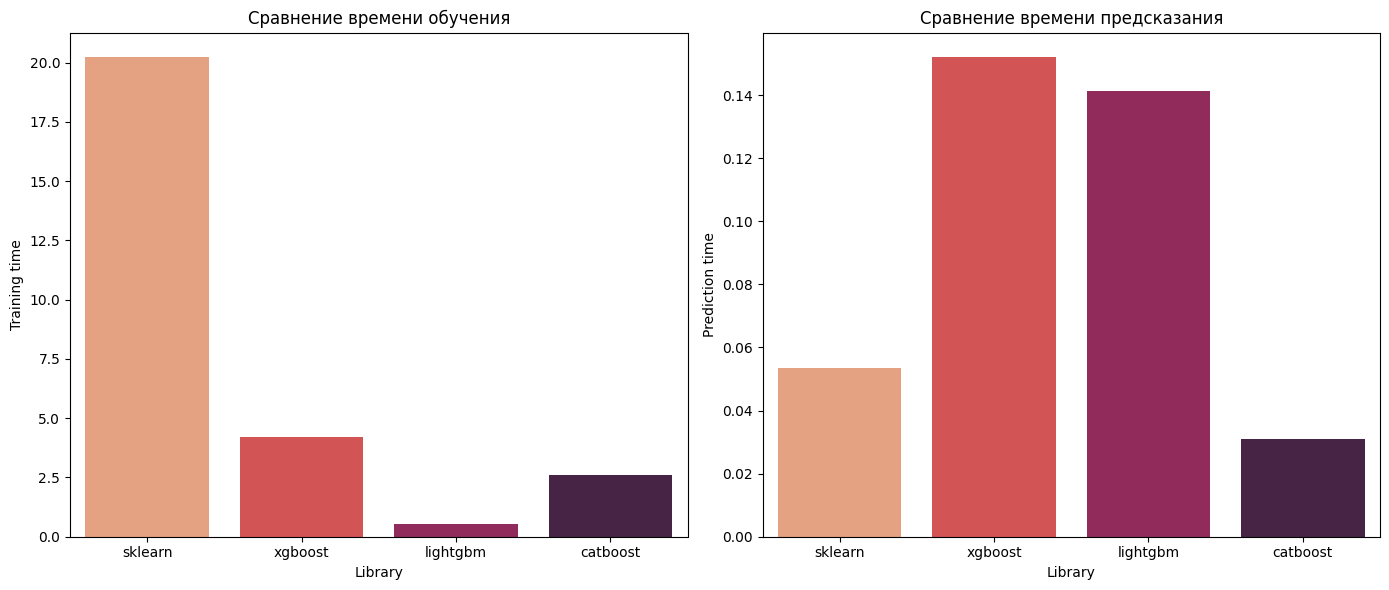

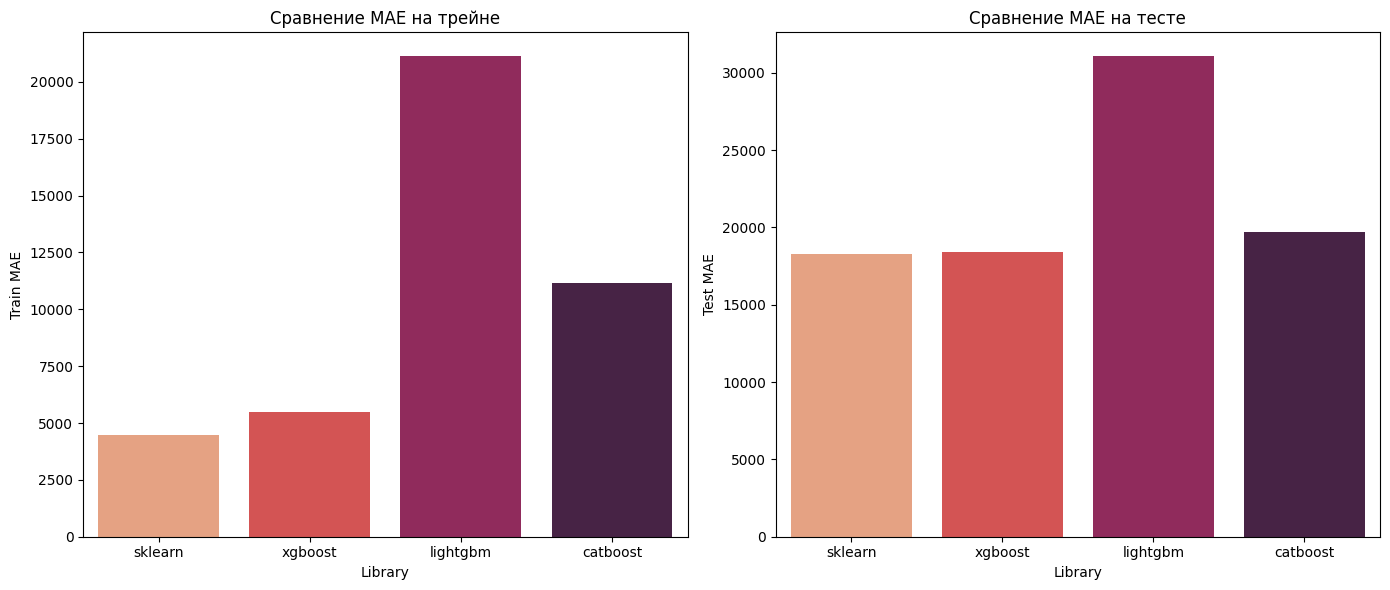

In [ ]:
import seaborn as sns


dataframes = [df_skl, df_xgb, df_lightgbm, df_catboost]
libraries = ['sklearn', 'xgboost', 'lightgbm', 'catboost']
data = []

for lib, df in zip(libraries, dataframes):
    df_filtered = df[df['Dataset'] == 'C']
    for _, row in df_filtered.iterrows():
        data.append({
            'Library': lib,
            'Dataset': 'C',
            'Training time': row['Training time'],
            'Prediction time': row['Prediction time'],
            'Train MAE': row['Train MAE'],
            'Test MAE': row['Test MAE']
        })

df_plot = pd.DataFrame(data)


plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.barplot(x='Library', y='Training time', data=df_plot, ci=None, palette='rocket_r')
plt.title('Сравнение времени обучения')
plt.subplot(1, 2, 2)
sns.barplot(x='Library', y='Prediction time', data=df_plot, ci=None, palette='rocket_r')
plt.title('Сравнение времени предсказания')
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.barplot(x='Library', y='Train MAE', data=df_plot, ci=None, palette='rocket_r')
plt.title('Сравнение MAE на трейне')
plt.subplot(1, 2, 2)
sns.barplot(x='Library', y='Test MAE', data=df_plot, ci=None, palette='rocket_r')
plt.title('Сравнение MAE на тесте')
plt.tight_layout()
plt.show()

Ваши выводы:
Сравнение времени обучения показывает, что sklearn требует значительно
больше времени, чем другие библиотеки и может не подойти в промышленных
задачах, lightgbm же по праву считается самым быстрым.

Сравнение времени предсказания демонстрирует, что lightgbm и xgboost
работают медленнее всех при предсказании, тогда как catboost и sklearn
показывают более низкое время предсказания.

Сравнение MAE на трейне показывает, что lightgbm имеет наибольшую
ошибку на обучающей выборке, что может указывать на недостаточное
обучение, в то время как sklearn и xgboost демонстрируют лучшие
результаты.

Сравнение MAE на тесте подтверждает, что lightgbm имеет наибольшую
ошибку, что может говорить о его недостаточной адаптации, а sklearn,
xgboost и catboost показывают более сбалансированные и примерно равные
результаты.